Author: Andreas Traut

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import OneHotEncoder  we will need this later
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [2]:
PATH = os.path.join("datasets", "movies")

In [3]:
def format_plot(ax, title, feature1, feature2):
    #ax.xaxis.set_major_formatter(plt.NullFormatter())
    #ax.yaxis.set_major_formatter(plt.NullFormatter())
    ax.set_xlabel(feature1, color='gray')
    ax.set_ylabel(feature2, color='gray')
    ax.set_title(title, color='gray')

# Importing the data

In [4]:
def load_data(path=PATH):
    csv_path = os.path.join(path, "movies.csv")
    return pd.read_csv(csv_path)

In [5]:
movies = load_data()
movies.head()

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description
0,1,The Shawshank Redemption,1994,9.3,80.0,Drama,2011509,Frank Darabont,142,28.34,Two imprisoned men bond over a number of years...
1,2,The Dark Knight,2008,9.0,84.0,"Action, Crime, Drama",1980200,Christopher Nolan,152,534.86,When the menace known as the Joker emerges fro...
2,3,Inception,2010,8.8,74.0,"Action, Adventure, Sci-Fi",1760209,Christopher Nolan,148,292.58,A thief who steals corporate secrets through t...
3,4,Fight Club,1999,8.8,66.0,Drama,1609459,David Fincher,139,37.03,An insomniac office worker and a devil-may-car...
4,5,Pulp Fiction,1994,8.9,94.0,"Crime, Drama",1570194,Quentin Tarantino,154,107.93,"The lives of two mob hitmen, a boxer, a gangst..."


In [6]:
movies.dtypes

Rank             int64
Title           object
Year             int64
Score          float64
Metascore      float64
Genre           object
Vote             int64
Director        object
Runtime          int64
Revenue        float64
Description     object
dtype: object

In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         10000 non-null  int64  
 1   Title        10000 non-null  object 
 2   Year         10000 non-null  int64  
 3   Score        10000 non-null  float64
 4   Metascore    6781 non-null   float64
 5   Genre        10000 non-null  object 
 6   Vote         10000 non-null  int64  
 7   Director     9999 non-null   object 
 8   Runtime      10000 non-null  int64  
 9   Revenue      7473 non-null   float64
 10  Description  10000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


# Filling "null" values

There are 7473 "non-null" values. And 2527 "null" values in column "Revenue":

In [8]:
10000-7473

2527

These are the datarows, where column "Revenue" is null: 

In [9]:
sample_incomplete_rows = movies[movies["Revenue"].isnull()]
sample_incomplete_rows

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description
82,83,A Clockwork Orange,1971,8.3,80.0,"Crime, Drama, Sci-Fi",662768,Stanley Kubrick,136,NaN,"In the future, a sadistic gang leader is impri..."
513,514,To Kill a Mockingbird,1962,8.3,87.0,"Crime, Drama",262064,Robert Mulligan,129,NaN,"Atticus Finch, a lawyer in the Depression-era ..."
581,582,Death Proof,2007,7.0,NaN,"Action, Thriller",236539,Quentin Tarantino,113,NaN,Two separate sets of voluptuous women are stal...
620,621,My Neighbour Totoro,1988,8.2,86.0,"Animation, Family, Fantasy",226126,Hayao Miyazaki,86,NaN,When two girls move to the country to be near ...
685,686,Hachi: A Dog's Tale,2009,8.1,NaN,"Drama, Family",212349,Lasse Hallström,93,NaN,A college professor's bond with the abandoned ...
...,...,...,...,...,...,...,...,...,...,...,...
9993,9994,The Infidel,2010,6.4,57.0,"Comedy, Drama",6024,Josh Appignanesi,105,NaN,An identity crisis comedy centred on Mahmud Na...
9996,9997,Stachka,1925,7.6,NaN,Drama,6021,Sergei M. Eisenstein,95,NaN,A group of oppressed factory workers go on str...
9997,9998,November Criminals,2017,5.3,31.0,"Crime, Drama, Mystery",6020,Sacha Gervasi,85,NaN,"After his friend is murdered, a Washington, D...."
9998,9999,120,2008,7.3,NaN,"Drama, History, War",6018,Özhan Eren,114,NaN,"During the Sarikamis Battle, the Ottoman army ..."


I want to fill these, e.g. with Median-values (which is a bad assumption, because a movie from the 1920th won't be comparable in "Revenue" to a movie form the 2020th. I will work on a better assumption later. 

In [10]:
median_Rev = movies["Revenue"].median()
median_Rev

15.09

In [11]:
movies["Revenue"].fillna(median_Rev, inplace=True)
movies

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description
0,1,The Shawshank Redemption,1994,9.3,80.0,Drama,2011509,Frank Darabont,142,28.34,Two imprisoned men bond over a number of years...
1,2,The Dark Knight,2008,9.0,84.0,"Action, Crime, Drama",1980200,Christopher Nolan,152,534.86,When the menace known as the Joker emerges fro...
2,3,Inception,2010,8.8,74.0,"Action, Adventure, Sci-Fi",1760209,Christopher Nolan,148,292.58,A thief who steals corporate secrets through t...
3,4,Fight Club,1999,8.8,66.0,Drama,1609459,David Fincher,139,37.03,An insomniac office worker and a devil-may-car...
4,5,Pulp Fiction,1994,8.9,94.0,"Crime, Drama",1570194,Quentin Tarantino,154,107.93,"The lives of two mob hitmen, a boxer, a gangst..."
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,When Night Is Falling,1995,6.6,NaN,"Drama, Romance",6022,Patricia Rozema,94,1.19,"An uptight and conservative woman, working on ..."
9996,9997,Stachka,1925,7.6,NaN,Drama,6021,Sergei M. Eisenstein,95,15.09,A group of oppressed factory workers go on str...
9997,9998,November Criminals,2017,5.3,31.0,"Crime, Drama, Mystery",6020,Sacha Gervasi,85,15.09,"After his friend is murdered, a Washington, D...."
9998,9999,120,2008,7.3,NaN,"Drama, History, War",6018,Özhan Eren,114,15.09,"During the Sarikamis Battle, the Ottoman army ..."


In [12]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         10000 non-null  int64  
 1   Title        10000 non-null  object 
 2   Year         10000 non-null  int64  
 3   Score        10000 non-null  float64
 4   Metascore    6781 non-null   float64
 5   Genre        10000 non-null  object 
 6   Vote         10000 non-null  int64  
 7   Director     9999 non-null   object 
 8   Runtime      10000 non-null  int64  
 9   Revenue      10000 non-null  float64
 10  Description  10000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


Now there are no "null"-values in column "Revenue" any more. 

Do the same for column "Metascore":

In [13]:
median_Metascore = movies["Metascore"].median()
median_Metascore
movies["Metascore"].fillna(median_Metascore, inplace=True)
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rank         10000 non-null  int64  
 1   Title        10000 non-null  object 
 2   Year         10000 non-null  int64  
 3   Score        10000 non-null  float64
 4   Metascore    10000 non-null  float64
 5   Genre        10000 non-null  object 
 6   Vote         10000 non-null  int64  
 7   Director     9999 non-null   object 
 8   Runtime      10000 non-null  int64  
 9   Revenue      10000 non-null  float64
 10  Description  10000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


# Visualisation of the data

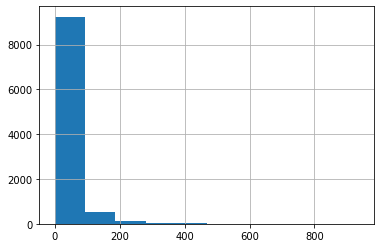

In [14]:
movies['Revenue'].hist()

Some scatter plots to see, how "Revenue", "Year" and "Score" behave: 

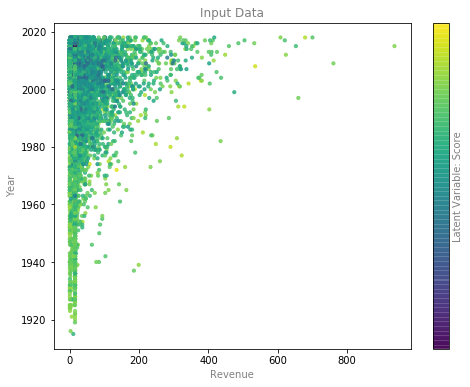

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
point_style = dict(cmap='Paired', s=50)
pts = ax.scatter(movies['Revenue'], movies['Year'], c=movies['Score'], s=10, alpha=0.8)
cb = fig.colorbar(pts, ax=ax)

# format plot
format_plot(ax, 'Input Data', 'Revenue', 'Year')
cb.set_ticks([])
cb.set_label('Latent Variable: Score', color='gray')

fig.savefig('images/movies/movies_revenue_year_score.png')

The Revenue increased during the years from 1920 to 2020. 

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000025C5939D388>,
      dtype=object)

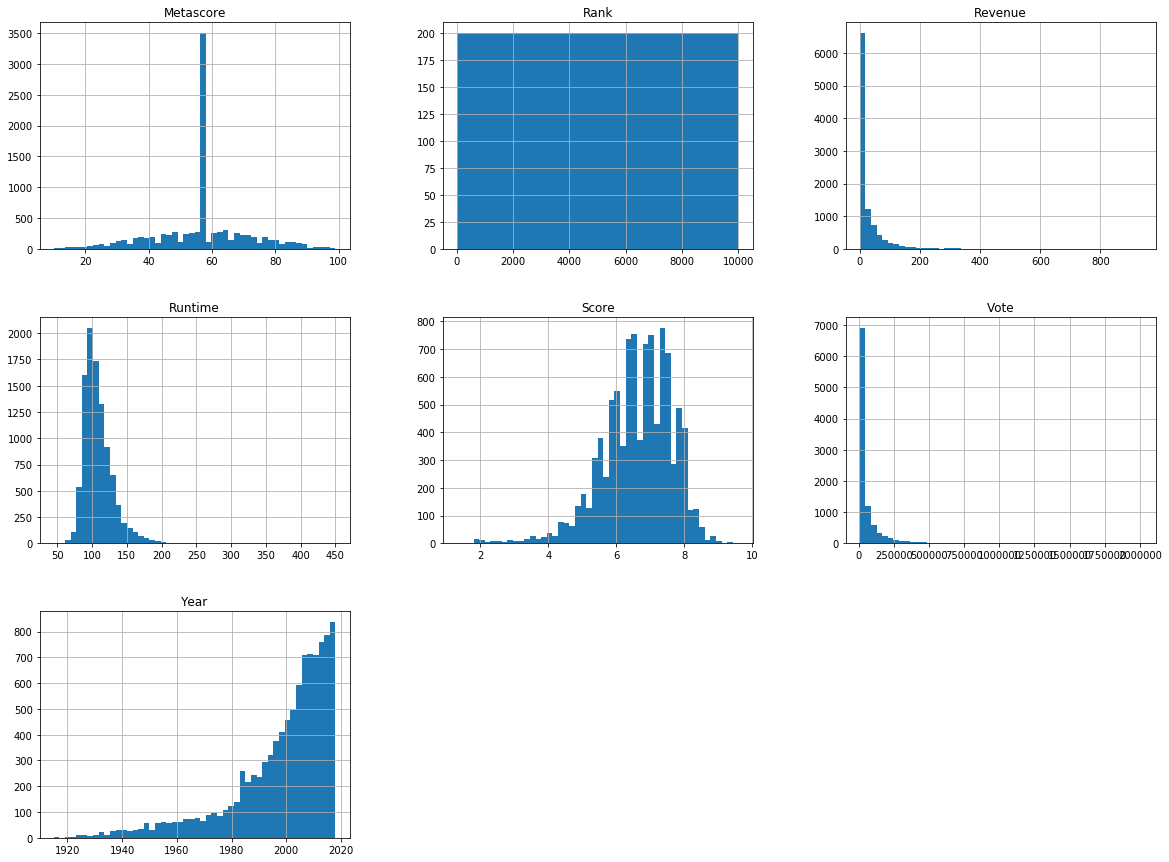

In [16]:
movies.hist(bins=50, figsize=(20,15))

Examine how "Year", "Score" and "Revenue" behave: 

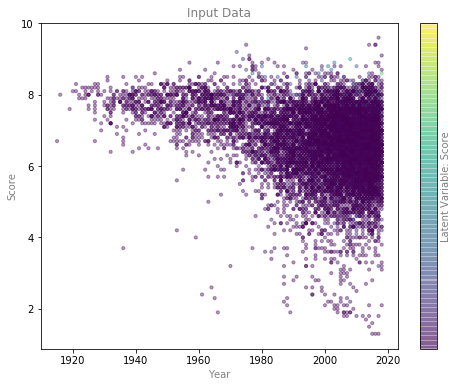

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
point_style = dict(cmap='Paired', s=50)
pts = ax.scatter(movies['Year'], movies['Score'], c=movies['Revenue'], s=10, alpha=0.4)
cb = fig.colorbar(pts, ax=ax)

# format plot
format_plot(ax, 'Input Data', 'Year', 'Score')
cb.set_ticks([])
cb.set_label('Latent Variable: Score', color='gray')

fig.savefig('images/movies/movies_year_score_revenue.png')

In 1920 most movies hat a score of 8. In 2020 most movies had a score between about 4 and 9. I think this is a bit strange, because I would have expected, that there are also movies with a lower score in 1920. 

# Stratified Sample

I want to draw a stratified sample with 4 buckets:

In [18]:
movies['RevCat']=pd.cut(movies['Revenue'], 
                        bins=[-1,80,200,300,np.inf], 
                        labels=[1, 2, 3, 4])
movies['RevCat'].value_counts()

1    9058
2     744
3     120
4      78
Name: RevCat, dtype: int64

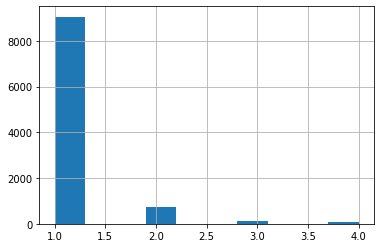

In [19]:
movies['RevCat'].hist()

In [20]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
for train_index, test_index in split.split(movies, movies["RevCat"]):
    strat_train_set = movies.loc[train_index]
    strat_test_set = movies.loc[test_index]

Examine, if each bucket in the stratified sample has the same quotient of datarows as the original movies-dataset:

In [21]:
strat_test_set["RevCat"].value_counts() / len(strat_test_set)

1    0.905875
2    0.074375
3    0.012000
4    0.007750
Name: RevCat, dtype: float64

In [22]:
movies["RevCat"].value_counts() / len(movies)

1    0.9058
2    0.0744
3    0.0120
4    0.0078
Name: RevCat, dtype: float64

Examine in detail how "good" every bucket is: 

In [23]:
def revenue_cat_proportions(data):
    return data["RevCat"].value_counts() / len(data)

train_set, test_set = train_test_split(movies, test_size=0.8, random_state=42)

compare_props = pd.DataFrame({
    "Overall": revenue_cat_proportions(movies),
    "Stratified": revenue_cat_proportions(strat_test_set),
    "Random": revenue_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

print(compare_props)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("RevCat", axis=1, inplace=True)

   Overall  Stratified    Random  Rand. %error  Strat. %error
1   0.9058    0.905875  0.904500     -0.143520       0.008280
2   0.0744    0.074375  0.075625      1.646505      -0.033602
3   0.0120    0.012000  0.012125      1.041667       0.000000
4   0.0078    0.007750  0.007750     -0.641026      -0.641026


We have successfully splittet the movies-database in a training-database "strat_train_set" and a testing-database "strat_test_set":

In [24]:
strat_train_set

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description
1959,1960,The Warriors,1979,7.7,65.0,"Action, Crime, Thriller",82912,Walter Hill,92,22.49,"In the near future, a charismatic leader summo..."
1957,1958,Edge of Darkness,2010,6.6,55.0,"Crime, Drama, Mystery",83023,Martin Campbell,117,43.31,As homicide detective Thomas Craven investigat...
4308,4309,The Three Stooges,2012,5.1,56.0,"Comedy, Family",27863,Bobby Farrelly,92,44.34,While trying to save their childhood orphanage...
3540,3541,Beneath the Planet of the Apes,1970,6.1,46.0,"Action, Adventure, Sci-Fi",37842,Ted Post,95,19.00,The sole survivor of an interplanetary rescue ...
9536,9537,The Yakuza,1974,7.3,57.0,"Action, Crime, Drama",6525,Sydney Pollack,107,15.09,American private-eye Harry Kilmer returns to J...
...,...,...,...,...,...,...,...,...,...,...,...
9925,9926,The 300 Spartans,1962,6.7,57.0,"Adventure, Drama, History",6087,Rudolph Maté,114,15.09,A small Army of Greeks spearheaded by three hu...
5554,5555,Ben X,2007,7.4,57.0,"Drama, Thriller",17529,Nic Balthazar,93,0.00,As an alternative to getting bullied at school...
7406,7407,Populaire,2012,6.9,58.0,"Comedy, Romance, Sport",10411,Régis Roinsard,111,0.18,1958. Rose is a terrible secretary but a demon...
291,292,The Conjuring,2013,7.5,68.0,"Horror, Mystery, Thriller",375621,James Wan,112,137.40,Paranormal investigators Ed and Lorraine Warre...


In [25]:
strat_test_set

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description
3176,3177,Black Rain,1989,6.6,56.0,"Action, Crime, Thriller",44244,Ridley Scott,125,46.21,Two NYC cops arrest a Yakuza member and must e...
1075,1076,Hot Tub Time Machine,2010,6.4,63.0,"Comedy, Sci-Fi",150924,Steve Pink,101,50.29,A malfunctioning time machine at a ski resort ...
7688,7689,Catch a Fire,2006,6.7,62.0,"Biography, Drama, History",9690,Phillip Noyce,101,4.29,A drama about terrorism in Apartheid-era South...
2596,2597,My Left Foot,1989,7.9,97.0,"Biography, Drama",59051,Jim Sheridan,103,14.74,"Christy Brown, born with cerebral palsy, learn..."
8853,8854,La rafle,2010,7.0,49.0,"Drama, History, War",7464,Rose Bosch,115,15.09,"A faithful retelling of the 1942 ""Vel' d'Hiv R..."
...,...,...,...,...,...,...,...,...,...,...,...
6489,6490,My Fellow Americans,1996,6.5,49.0,"Adventure, Comedy",13233,Peter Segal,101,22.29,"Two former U. S. Presidents, hated rivals, joi..."
1443,1444,Blazing Saddles,1974,7.8,73.0,"Comedy, Western",112018,Mel Brooks,93,119.50,"In order to ruin a western town, a corrupt pol..."
1865,1866,A Prophet,2009,7.9,90.0,"Crime, Drama",86501,Jacques Audiard,155,2.08,A young Arab man is sent to a French prison.
3246,3247,French Kiss,1995,6.6,50.0,"Comedy, Drama, Romance",42868,Lawrence Kasdan,111,38.90,A woman flies to France to confront her strayi...


I want to predict the "Revenue" based on the other columns (year, score,...). Therfore I split the training set into the "movies_train" (the input variables) and the "movies_train_labels" (the value, which I want to predict: 

In [26]:
movies_train = strat_train_set.drop('Revenue', axis=1)
movies_train_labels = strat_train_set['Revenue'].copy()

In [27]:
movies_train

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Description
1959,1960,The Warriors,1979,7.7,65.0,"Action, Crime, Thriller",82912,Walter Hill,92,"In the near future, a charismatic leader summo..."
1957,1958,Edge of Darkness,2010,6.6,55.0,"Crime, Drama, Mystery",83023,Martin Campbell,117,As homicide detective Thomas Craven investigat...
4308,4309,The Three Stooges,2012,5.1,56.0,"Comedy, Family",27863,Bobby Farrelly,92,While trying to save their childhood orphanage...
3540,3541,Beneath the Planet of the Apes,1970,6.1,46.0,"Action, Adventure, Sci-Fi",37842,Ted Post,95,The sole survivor of an interplanetary rescue ...
9536,9537,The Yakuza,1974,7.3,57.0,"Action, Crime, Drama",6525,Sydney Pollack,107,American private-eye Harry Kilmer returns to J...
...,...,...,...,...,...,...,...,...,...,...
9925,9926,The 300 Spartans,1962,6.7,57.0,"Adventure, Drama, History",6087,Rudolph Maté,114,A small Army of Greeks spearheaded by three hu...
5554,5555,Ben X,2007,7.4,57.0,"Drama, Thriller",17529,Nic Balthazar,93,As an alternative to getting bullied at school...
7406,7407,Populaire,2012,6.9,58.0,"Comedy, Romance, Sport",10411,Régis Roinsard,111,1958. Rose is a terrible secretary but a demon...
291,292,The Conjuring,2013,7.5,68.0,"Horror, Mystery, Thriller",375621,James Wan,112,Paranormal investigators Ed and Lorraine Warre...


In [28]:
movies_train_labels

1959     22.49
1957     43.31
4308     44.34
3540     19.00
9536     15.09
         ...  
9925     15.09
5554      0.00
7406      0.18
291     137.40
731     162.00
Name: Revenue, Length: 2000, dtype: float64

I do the same for the testing dataset: 

In [29]:
movies_test = strat_test_set.drop('Revenue', axis=1)
movies_test_labels = strat_test_set['Revenue'].copy()

# Pipeline

Now I want to implement a pipeline for doing all the datapreparation work quicker when I am testing it later. Only numerical-columns will be taken. The other will be thrown away (for the moment, I will change this later): 

In [30]:
imputer = SimpleImputer(strategy="median")
movies_train_num = movies_train.select_dtypes(include=[np.number])
imputer.fit(movies_train_num)
X = imputer.transform(movies_train_num) # Transform the training set:
movies_tr = pd.DataFrame(X, columns=movies_train_num.columns,index=movies_train.index)
movies_tr

,Rank,Year,Score,Metascore,Vote,Runtime
1959,1960.0,1979.0,7.7,65.0,82912.0,92.0
1957,1958.0,2010.0,6.6,55.0,83023.0,117.0
4308,4309.0,2012.0,5.1,56.0,27863.0,92.0
3540,3541.0,1970.0,6.1,46.0,37842.0,95.0
9536,9537.0,1974.0,7.3,57.0,6525.0,107.0
...,...,...,...,...,...,...
9925,9926.0,1962.0,6.7,57.0,6087.0,114.0
5554,5555.0,2007.0,7.4,57.0,17529.0,93.0
7406,7407.0,2012.0,6.9,58.0,10411.0,111.0
291,292.0,2013.0,7.5,68.0,375621.0,112.0


In [31]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
])

num_attribs = list(movies_train_num)

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs)
])

Apply the full pipleine on the training-dataset "movies_train"

In [32]:
movies_train_prepared = full_pipeline.fit_transform(movies_train)

# Model "DecisionTreeRegressor"

In [33]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(movies_train_prepared, movies_train_labels)

movies_predictions = tree_reg.predict(movies_train_prepared)

Verifiy if training labels ("movies_train_labels") and predicted labels ("movies_predictions"). Here for the first 10 datasets:

In [34]:
movies_train_labels[0:10]

1959     22.49
1957     43.31
4308     44.34
3540     19.00
9536     15.09
9708     15.09
3294      0.37
5532      0.15
714     114.33
2557     13.04
Name: Revenue, dtype: float64

In [35]:
movies_predictions[0:10]

array([ 22.49,  43.31,  44.34,  19.  ,  15.09,  15.09,   0.37,   0.15,
       114.33,  13.04])

The training-labels and the predicted labels match for the first 10 datasets. The fitting of the model was successful.

How big is the error for all training-datasets?

In [36]:
lin_mse = mean_squared_error(movies_train_labels, movies_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

1.502571100062335e-15

# Cross-Validation

In [37]:
scores = cross_val_score(tree_reg, 
                         movies_train_prepared,
                         movies_train_labels,
                         scoring="neg_mean_squared_error", 
                         cv=10)

rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(rmse_scores)

Scores: [59.61243929 41.34568424 50.51738622 51.14042647 65.32569421 50.78576682
 41.4726238  40.72683195 33.77546372 40.17441105]
Mean: 47.48767277683459
Standard deviation: 9.27214349221812


# Test the model

Take for example this dataset (from the testing-dataset "movies_test"):

In [38]:
some_data = movies_test.iloc[[322]]
some_data_label = movies_test_labels.iloc[[322]]

In [39]:
some_data

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Description
2593,2594,Nanny McPhee,2005,6.6,59.0,"Comedy, Family, Fantasy",59137,Kirk Jones,97,A governess uses magic to rein in the behavior...


In [40]:
some_data_label

2593    47.14
Name: Revenue, dtype: float64

This is the same as the folling dataset from the original "movies"-database:

In [41]:
movies.iloc[[2593]]

,Rank,Title,Year,Score,Metascore,Genre,Vote,Director,Runtime,Revenue,Description,RevCat
2593,2594,Nanny McPhee,2005,6.6,59.0,"Comedy, Family, Fantasy",59137,Kirk Jones,97,47.14,A governess uses magic to rein in the behavior...,1


Lets predict the revenue for this dataset:

In [42]:
some_data_prepared =full_pipeline.fit_transform(some_data)
some_data_predictions = tree_reg.predict(some_data_prepared)
some_data_predictions

array([51.39])

Compare this prediction to the value "some_data_label" above. The error is as follows: 

In [43]:
lin_mse = mean_squared_error(some_data_label, some_data_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

4.25

Do this test on another movie:

In [44]:
def testing_model(i):
    print(i)
    some_data = movies_test.iloc[[i]]
    some_data_label = movies_test_labels.iloc[[i]]
    print("Revenue: %2.2f" %(some_data_label))

    some_data_prepared =full_pipeline.fit_transform(some_data)
    some_data_predictions = tree_reg.predict(some_data_prepared)
    print("Prediction: %2.2f" %(some_data_predictions))

    lin_mse = mean_squared_error(some_data_label, some_data_predictions)
    lin_rmse = np.sqrt(lin_mse)
    print("Error: %2.2f\n" %(lin_rmse))
    
testing_model(322)
testing_model(323)
testing_model(400)

322
Revenue: 47.14
Prediction: 51.39
Error: 4.25

323
Revenue: 31.80
Prediction: 82.42
Error: 50.62

400
Revenue: 15.09
Prediction: 0.07
Error: 15.02

